# 01 EDA

Load Retailrocket logs, inspect data quality, and build daily metrics.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [2]:
from src.data_processing import load_events, basic_summary, build_daily_metrics
from src.visualization import plot_dau, plot_event_volume, plot_conversion_rates

EVENTS_PATH = "C:/Users/chuan/OneDrive/Desktop/Intern_Prepare/业务准备/ecommerce-user-retention-analysis/data/events.csv"
OUTPUT_FIG = Path("outputs/figures")
OUTPUT_TABLE = Path("outputs/tables")
OUTPUT_FIG.mkdir(parents=True, exist_ok=True)
OUTPUT_TABLE.mkdir(parents=True, exist_ok=True)

df = load_events(EVENTS_PATH)
summary = basic_summary(df)
summary

{'n_rows': 2755641,
 'n_users': 1407580,
 'n_items': 235061,
 'start_date': '2015-05-03',
 'end_date': '2015-09-18',
 'n_days': 139}

In [3]:
daily = build_daily_metrics(df)
daily.head()

,date,dau,addtocart,transaction,view,view_to_cart_rate,cart_to_buy_rate,view_to_buy_rate
0,2015-05-03,7865,296,83,13303,0.022251,0.280405,0.006239
1,2015-05-04,11019,578,154,18681,0.030941,0.266436,0.008244
2,2015-05-05,13084,561,225,22225,0.025242,0.401070,0.010124
3,2015-05-06,13687,647,258,23015,0.028112,0.398764,0.011210
4,2015-05-07,13086,572,217,22368,0.025572,0.379371,0.009701


In [4]:
daily.describe(include="all")

,date,dau,addtocart,transaction,view,view_to_cart_rate,cart_to_buy_rate,view_to_buy_rate
count,139,139.000000,139.000000,139.000000,139.000000,139.000000,139.000000,139.000000
mean,2015-07-11 00:00:00,11867.151079,496.158273,161.561151,19167.035971,0.025864,0.318846,0.008280
min,2015-05-03 00:00:00,1016.000000,34.000000,15.000000,1479.000000,0.014683,0.179283,0.004369
25%,2015-06-06 12:00:00,10292.000000,391.500000,112.500000,16344.000000,0.023810,0.274864,0.006801
50%,2015-07-11 00:00:00,12348.000000,509.000000,162.000000,19961.000000,0.025534,0.323478,0.008316
75%,2015-08-14 12:00:00,13151.000000,580.500000,207.500000,21787.500000,0.028116,0.365779,0.009715
max,2015-09-18 00:00:00,17516.000000,799.000000,276.000000,32077.000000,0.036897,0.441176,0.013009
std,NaN,2303.606146,124.599140,58.246368,4024.284121,0.003570,0.058297,0.002024


In [5]:
plot_dau(daily, OUTPUT_FIG)
plot_event_volume(daily, OUTPUT_FIG)
plot_conversion_rates(daily, OUTPUT_FIG)

'outputs\\figures\\conversion_rates.png'

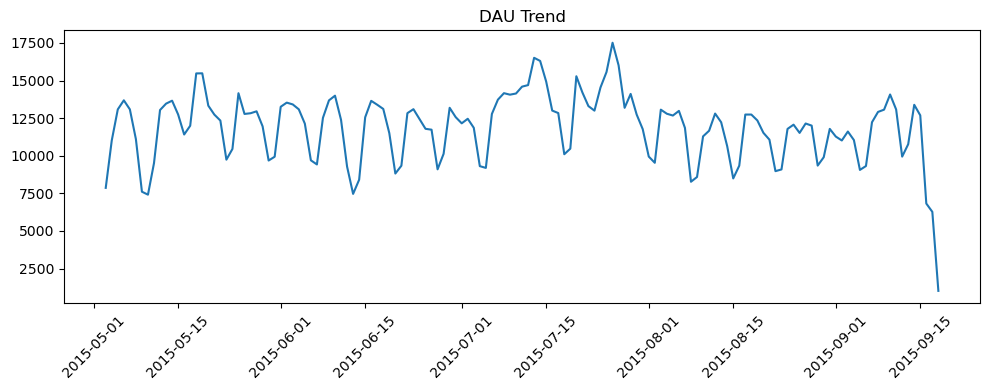

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(daily["date"], daily["dau"])
plt.xticks(rotation=45)
plt.title("DAU Trend")
plt.tight_layout()
plt.show()

In [7]:
df["event"].value_counts()

event
view           2664218
addtocart        68966
transaction      22457
Name: count, dtype: int64

In [8]:
daily["dau"].mean()

11867.15107913669

In [9]:
daily["dau"].max()

17516

In [10]:
daily["dau"].min()

1016